In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import mint
from mint import plot_tools as pt
from mint import lattice_tools as lt

from mint.MuC import MuDecaySimulator

## Linear Accelerator

In [3]:
PA_numu = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

PA_nue = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='nue',
    direction="right",
    n_evals=1e6,
    )

PA_numu.decay_muons()
PA_nue.decay_muons()

In [4]:
straight_lattice = lt.create_straight_lattice(
            name= r"PA",
            short_name= "pa",
            total_length=160e2,
            n_elements=100_000,
            beamdiv=1e-3,
            beamdiv_z=1e-2,
            beamsize=1,
            Nmu_per_bunch=2e12,
        )

Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x12f27ba20>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x11f2282c0>
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent'])


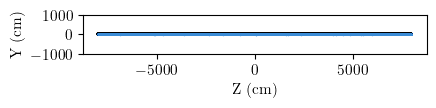

In [5]:
PA_numu.place_muons_on_lattice(lattice=straight_lattice, direction="clockwise")
PA_nue.place_muons_on_lattice(lattice=straight_lattice, direction="clockwise")

plt.scatter(straight_lattice.vertices[0], straight_lattice.vertices[1], c='black', marker='+', s=10)
plt.scatter(PA_numu.pos['z'], PA_numu.pos['y'], marker='.', s=0.1)
plt.ylim(-1000, 1000)
plt.xlabel('Z (cm)')
plt.ylabel('Y (cm)')
plt.gca().set_aspect('equal', adjustable='box')

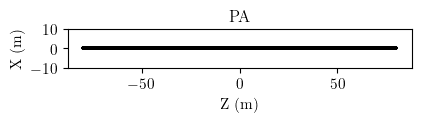

In [6]:
plt.scatter(straight_lattice.vertices[0]/100, straight_lattice.vertices[1]/100, c='black', marker='+', s=10)
#plt.scatter(PA_numu.pos['z'], PA_numu.pos['y'], marker='.', s=0.1)
plt.ylim(-10, 10)
plt.xlabel('Z (m)')
plt.ylabel('X (m)')
plt.title("PA")
plt.gca().set_aspect('equal', adjustable='box')

## RLA1

In [7]:
RLA1_numu = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

RLA1_nue = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='nue',
    direction="right",
    n_evals=1e6,
    )

RLA1_numu.decay_muons()
RLA1_nue.decay_muons()


Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x12f66e120>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x12f65ade0>
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent'])


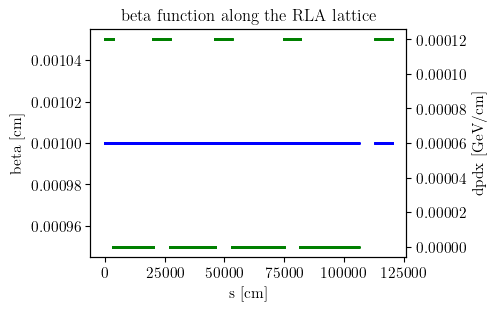

In [8]:

RLA1_lattice = lt.create_RLA_lattice(
            name = r"RLA1",
            short_name= "rla1",
            straight_length=70e2,
            n_elements=100_000,
            p0_injection=1.25,
            dp_dx_LA=0.84/70e2,
            beamdiv=1e-3,
            beamdiv_z=1e-2,
            beamsize=1e-2,
            Nmu_per_bunch=2e12,
            beam_dyn=False,
        )

Text(0.5, 1.0, 'RLA 1')

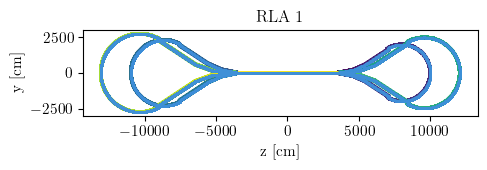

In [9]:
RLA1_nue.place_muons_on_lattice(lattice=RLA1_lattice, direction="clockwise")
RLA1_numu.place_muons_on_lattice(lattice=RLA1_lattice, direction="clockwise")

max_index = len(RLA1_lattice.vertices[1])

fig, ax = pt.std_fig(figsize=(5, 2))
ax.scatter(RLA1_lattice.vertices[0], RLA1_lattice.vertices[1], c=np.linspace(0,1,max_index), marker='+', s=10)
ax.scatter(RLA1_numu.pos['z'], RLA1_numu.pos['x'], marker='.', s=0.25)

fig.gca().set_aspect('equal', adjustable='box')

ax.set_xlabel("z [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("RLA 1")

Text(0.5, 1.0, 'RLA 1')

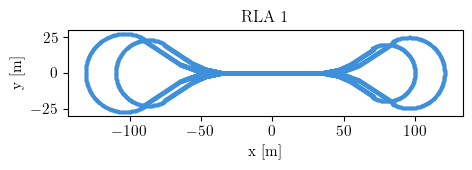

In [10]:
fig, ax = pt.std_fig(figsize=(5, 2))
ax.scatter(RLA1_lattice.vertices[0]/100, RLA1_lattice.vertices[1]/100, marker='.', s=10)

fig.gca().set_aspect('equal', adjustable='box')

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("RLA 1")

## RLA2

In [11]:

RLA2_numu = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

RLA2_nue = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='nue',
    direction="right",
    n_evals=1e6,
    )

RLA2_numu.decay_muons()
RLA2_nue.decay_muons()

[ 2157.68        2160.60501144  2163.53002288 ... 17587.56156373
 17590.48657517 17593.4115866 ]
Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x10bab94f0>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x10d3ca480>
Setting additional beamdiv to 0.001
Setting additional beamsize to 0.01
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent', 'beamdiv', 'beamsize'])


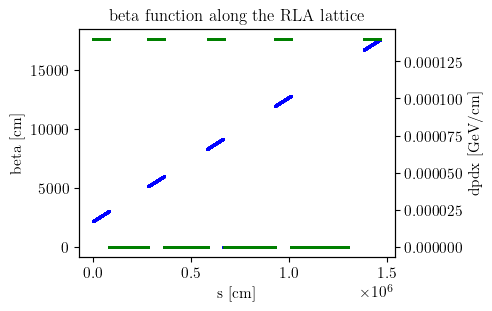

In [12]:
RLA2_lattice = lt.create_RLA_lattice(
            name = r"RLA2",
            short_name= "rla2",
            straight_length=829e2,
            n_elements=100_000,
            p0_injection=5.0,
            dp_dx_LA=11.6/829e2,
            beamdiv=1e-3,
            beamdiv_z=1e-2,
            beamsize=1e-2,
            half=False,
            Nmu_per_bunch=2e12,
            beam_dyn=True,
)

In [13]:
u_vals = np.linspace(0, 1, 2000)
print(type(u_vals), u_vals.shape)
print(RLA2_lattice.beamsize_x)

<class 'numpy.ndarray'> (2000,)


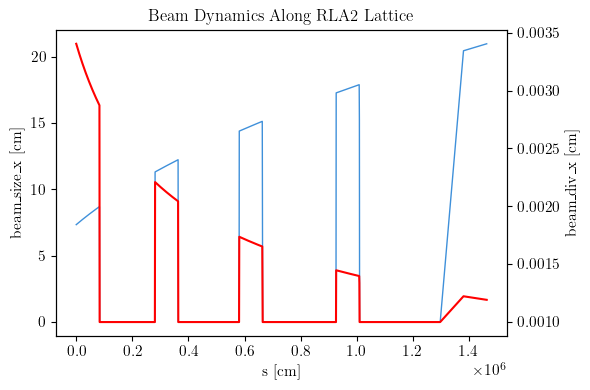

In [14]:
# u ranges from 0 → 1
u_vals = np.linspace(0, 1, 2000)

# Convert to actual s-position (in cm):
s_vals = u_vals * 1463126.8482550883   # or lattice.length

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(s_vals, RLA2_lattice.beamsize_x(u_vals), linewidth=1.0)

ax2 = ax.twinx()
ax2.plot(s_vals, RLA2_lattice.beamdiv_x(u_vals), color="red")

ax.set_xlabel("s [cm]")
ax.set_ylabel("beam_size_x [cm]")
ax2.set_ylabel("beam_div_x [cm]")
ax.set_title("Beam Dynamics Along RLA2 Lattice")
plt.tight_layout()
plt.show()

fig.savefig("plots/RLA2_BD.pdf", dpi=400)

Text(0.5, 1.0, 'RLA 2')

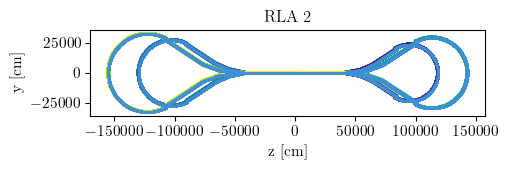

In [15]:
RLA2_nue.place_muons_on_lattice(lattice=RLA2_lattice, direction="clockwise")
RLA2_numu.place_muons_on_lattice(lattice=RLA2_lattice, direction="clockwise")

max_index = len(RLA2_lattice.vertices[1])

fig, ax = pt.std_fig(figsize=(5, 2))
ax.scatter(RLA2_lattice.vertices[0], RLA2_lattice.vertices[1], c=np.linspace(0, 1, max_index), marker='+', s=10)
ax.scatter(RLA2_numu.pos['z'], RLA2_numu.pos['x'], marker='.', s=0.25)

fig.gca().set_aspect('equal', adjustable='box')

ax.set_xlabel("z [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("RLA 2")

Text(0.5, 1.0, 'RLA 2')

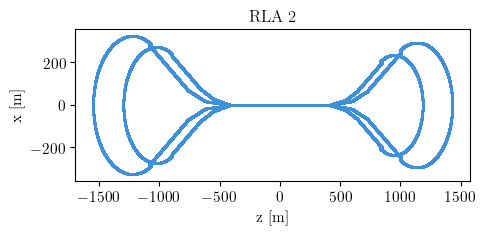

In [16]:
fig, ax = pt.std_fig(figsize=(5, 2))
ax.scatter(RLA2_numu.pos['z']/100, RLA2_numu.pos['x']/100, marker='.', s=0.25)
ax.set_xlabel("z [m]")
ax.set_ylabel("x [m]")
ax.set_title("RLA 2")

In [17]:
def plot_avgE_vs_time(MuC_acc_numu, MuC_acc_nue):
    # Bin mutimes and compute average neutrino energy in each bin
    bins = np.linspace(MuC_acc_numu.mutimes.min(), MuC_acc_numu.mutimes.max(), 50)
    digitized = np.digitize(MuC_acc_numu.mutimes, bins)
    avg_mu_E = [MuC_acc_numu.pmu['E'][digitized == i].mean() if np.any(digitized == i) else np.nan for i in range(1, len(bins))]
    avg_numu_E = [MuC_acc_numu.pnu['E'][digitized == i].mean() if np.any(digitized == i) else np.nan for i in range(1, len(bins))]
    bins = np.linspace(MuC_acc_nue.mutimes.min(), MuC_acc_nue.mutimes.max(), 50)
    digitized = np.digitize(MuC_acc_nue.mutimes, bins)
    avg_nue_E = [MuC_acc_nue.pnu['E'][digitized == i].mean() if np.any(digitized == i) else np.nan for i in range(1, len(bins))]

    fig, ax = pt.std_fig(figsize=(4,3))
    ax.step(1e6*bins[:-1], avg_mu_E, linestyle='-', color='grey', label=r'$\langle E_{\mu} \rangle$')
    ax.step(1e6*bins[:-1], avg_nue_E, linestyle='-', color='darkorange', label=r'$\langle E_{\nu_e} \rangle$')
    ax.step(1e6*bins[:-1], avg_numu_E, linestyle='-', color='dodgerblue', label=r'$\langle E_{\nu_\mu} \rangle$')
    ax.set_xlabel('time ($\mu$s)')
    ax.set_ylabel(r'Average neutrino energy [GeV]')
    ax.legend(frameon=False, loc='upper left')
    return fig, ax

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='time ($\\mu$s)', ylabel='Average neutrino energy [GeV]'>)

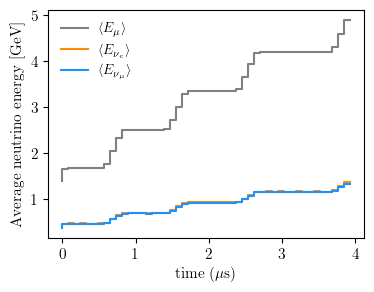

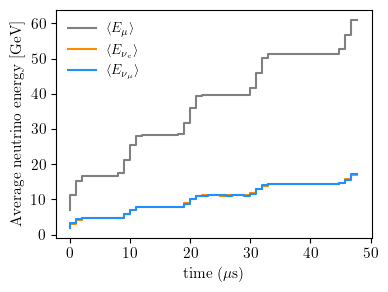

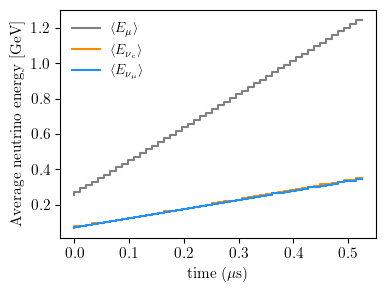

In [18]:
plot_avgE_vs_time(RLA1_numu, RLA1_nue)
plot_avgE_vs_time(RLA2_numu, RLA2_nue)
plot_avgE_vs_time(PA_numu, PA_nue)

## Combine the Accelerators

In [19]:
combined_numu = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

combined_nue = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='nue',
    direction="right",
    n_evals=1e6,
    )

combined_numu.decay_muons()
combined_nue.decay_muons()

In [20]:
combined_lattice =lt.append_lattices(
    lt.append_lattices(
            straight_lattice,
            RLA1_lattice,
            -20e2,
            -29.11e2),
    RLA2_lattice,
    -20e2,
    1550.1e2-165.89e2,
    RLA=True
)

Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x31fb705f0>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x31fa4d620>
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent'])
is same; lattice nmu per bunch is: 2000000000000.0
Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x31fb70c80>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x31fb0b600>
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent'])
is same; lattice nmu per bunch is: 2000000000000.0


Text(0.5, 1.0, 'Combined Accelerators')

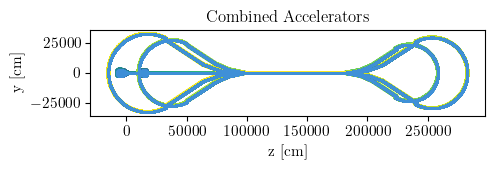

In [21]:
combined_numu.place_muons_on_lattice(lattice=combined_lattice, direction="clockwise")
combined_nue.place_muons_on_lattice(lattice=combined_lattice, direction="clockwise")

max_index = len(combined_lattice.vertices[1])

fig, ax = pt.std_fig(figsize=(5, 2))
ax.scatter(combined_lattice.vertices[0], combined_lattice.vertices[1], c=np.linspace(0,1,max_index), marker='+', s=10)
ax.scatter(combined_numu.pos['z'], combined_numu.pos['x'], marker='.', s=0.25)

fig.gca().set_aspect('equal', adjustable='box')

ax.set_xlabel("z [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Combined Accelerators")

Text(0.5, 1.0, 'PA+RLA1+RLA2')

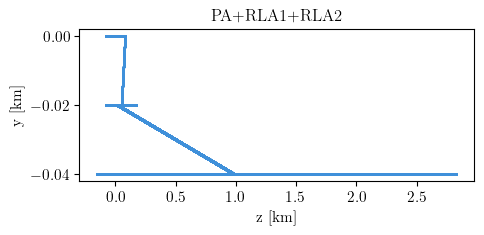

In [22]:
fig, ax = pt.std_fig(figsize=(5, 2))
ax.scatter(combined_numu.pos['z']/1e5, combined_numu.pos['y']/1e5, marker='.', s=0.25)
ax.set_xlabel("z [km]")
ax.set_ylabel("y [km]")
ax.set_title(combined_lattice.name)

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='time ($\\mu$s)', ylabel='Average neutrino energy [GeV]'>)

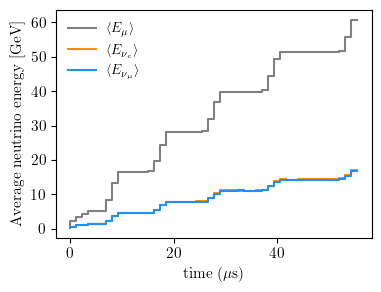

In [23]:
plot_avgE_vs_time(combined_numu,combined_nue)

## Event Maps

In [24]:
def get_event_map_fixed_z(
        numu,
        detect_loc,
        xrange=(-5000, 5000),
        yrange=(-77245, 1e3),
        nx=100,
        ny=100,
        det_radius=1e2,
    ):
        # print(np.max(self.mutimes))
        # print(np.sum(self.weights[:,0]))

        p_dir = numu.pnu.to_3D().unit()

        event_map = np.zeros((nx, ny))
        X = None
        Y = None

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - numu.pos["z"]) / p_dir["z"]
            x_hit = numu.pos["x"] + t_vals * p_dir["x"]
            y_hit = numu.pos["y"] + t_vals * p_dir["y"]

            r2 = x_hit**2 + (y_hit + y_offset) ** 2
            in_acceptance = (t_vals > 0) & (r2 < det_radius**2)

            sigma = numu.pnu["E"][in_acceptance] * 1e-38
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            events, x_arr, y_arr = np.histogram2d(
                x_hit[in_acceptance],
                y_hit[in_acceptance],
                bins=[nx, ny],
                range=[xrange, yrange],
                weights=numu.weights[in_acceptance, 0] * P_int,
            )

            event_map += events  # accumulate directly, no concatenation

            event_map *= 5 * np.pi * 1e7  # 5 Hz injection rate * seconds in a year
            if X is None:
                X, Y = x_arr, y_arr

                
        total_events = np.sum(event_map)
        return X, Y, event_map, total_events

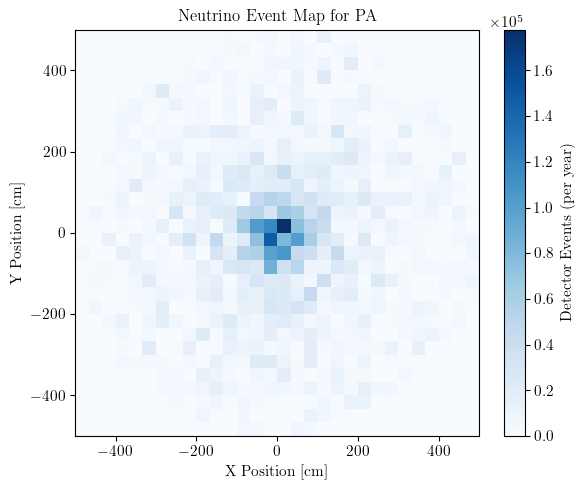

In [25]:
X, Y, event_map, _ = get_event_map_fixed_z(
    combined_numu,
    detect_loc=[(85e2, 0)],
    xrange=(-500,500),  
    yrange=(-5e2, 5e2),      
    nx=30,
    ny=30,
    det_radius=5e2              # 10m detector
)

# Visualization
# plt.figure(figsize=(6, 5))
# c = plt.pcolormesh(X, Y, event_map.T, shading='auto', cmap='Blues', vmin=1e-10)
# plt.colorbar(c, label='Detector Events (per year)')
# plt.xlabel('X Position [cm]')
# plt.ylabel('Y Position [cm]')
# plt.title(f"Neutrino Event Map for PA")
# plt.tight_layout()
# plt.show()

import matplotlib.ticker as ticker

plt.figure(figsize=(6, 5))
c = plt.pcolormesh(X, Y, event_map.T, shading='auto', cmap='Blues', vmin=1e-10)
cb = plt.colorbar(c, label='Detector Events (per year)')

# Force scientific notation on the colorbar
cb.formatter = ticker.ScalarFormatter()
cb.formatter.set_powerlimits((-2, 2))   # scientific notation outside [-2, 2]
cb.update_ticks()

plt.xlabel('X Position [cm]')
plt.ylabel('Y Position [cm]')
plt.title("Neutrino Event Map for PA")
plt.tight_layout()
plt.show()

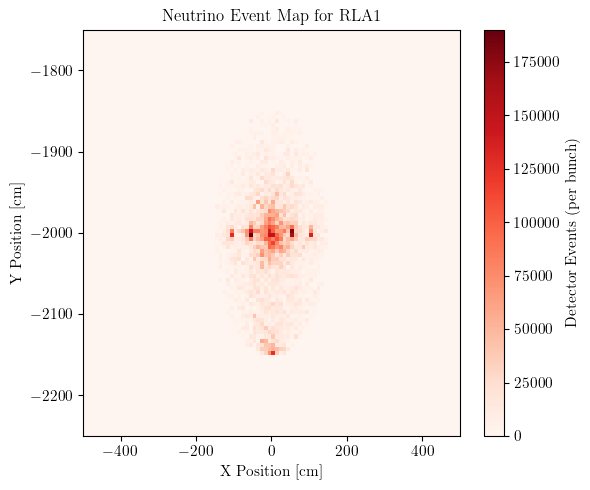

In [26]:
X, Y, event_map,_ = get_event_map_fixed_z(
    combined_numu,
    detect_loc=[(91.6821e2, 20e2)],
    #detect_loc=[(1e5, 20e2)],
    xrange=(-500,500),  
    yrange=(-22.5e2, -17.5e2),      
    nx=100,
    ny=100,
    det_radius=1.5e2              # 10m detector
)

# Visualization
plt.figure(figsize=(6, 5))
c = plt.pcolormesh(X, Y, event_map.T, shading='auto', cmap='Reds', vmin=0)
plt.colorbar(c, label='Detector Events (per bunch)')
plt.xlabel('X Position [cm]')
plt.ylabel('Y Position [cm]')
plt.title(f"Neutrino Event Map for RLA1")
plt.tight_layout()
plt.show()

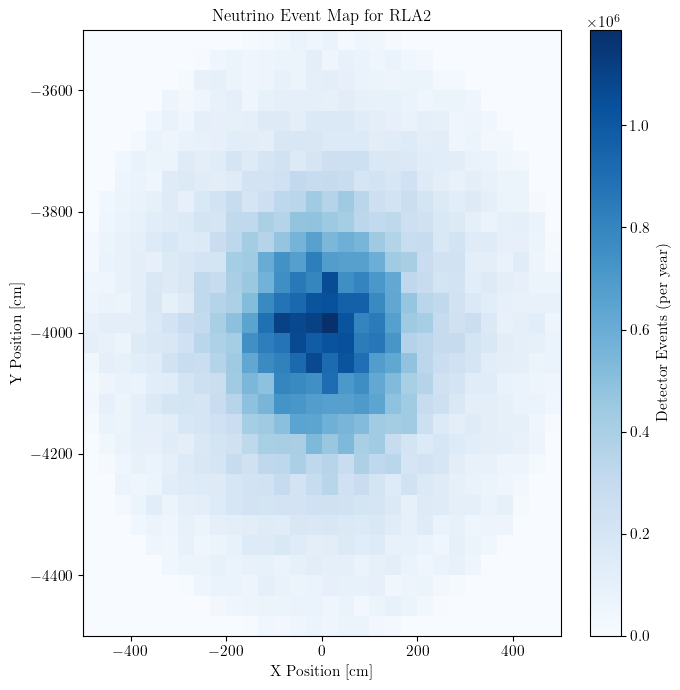

In [27]:
X, Y, event_map,_ = get_event_map_fixed_z(
    combined_numu,
    detect_loc=[(2835.62e2, 40e2)],
    xrange=(-500,500),  
    yrange=(-45e2, -35e2),      
    nx=30,
    ny=30,
    det_radius=5e2              # 10m detector
)

# Visualization
plt.figure(figsize=(7, 7))
c = plt.pcolormesh(X, Y, event_map.T, shading='auto', cmap='Blues', vmin=0)
cb = plt.colorbar(c, label='Detector Events (per year)')

cb.formatter = ticker.ScalarFormatter()
cb.formatter.set_powerlimits((-2, 2))   # scientific notation outside [-2, 2]
cb.update_ticks()

plt.xlabel('X Position [cm]')
plt.ylabel('Y Position [cm]')
plt.title(f"Neutrino Event Map for RLA2")
plt.tight_layout()
plt.show()

## Compare BD vs. No BD for RLA2

In [28]:
def get_event_rate_at_annuli_event_based(sim, det_loc, r_edges):
    """
    Event-based binning: for each event, compute its radial distance to the detector axis, bin its weight into the appropriate annulus, and apply the probability of interaction at the detector.
    Returns: event rate per annulus (events per year per m)
    """
    import vector
    # Get event positions and directions
    det_vector = vector.array({"x": det_loc[0], "y": det_loc[1], "z": det_loc[2]})
    distances = det_vector - sim.pos
    neutrino_direction = sim.pnu.to_3D().unit()
    sintheta = np.sqrt(1 - distances.unit().dot(neutrino_direction) ** 2)
    radial_distance = sintheta * distances.mag

    # Only consider events that are forward-going and within energy range
    dotprod = distances.dot(neutrino_direction)
    in_acceptance = (dotprod > 0) & (sim.pnu["E"] > 0)

    # Bin by radial distance
    r_edges = np.asarray(r_edges)
    weights = sim.weights.flatten()
    # Only use accepted events
    r_accepted = radial_distance[in_acceptance]
    w_accepted = weights[in_acceptance]

    sigma = sim.pnu["E"][in_acceptance] * 1e-38
    P_int = (1 / 1.67262192e-24) * sigma * 10e2

    event_weights = w_accepted * P_int * 5 * np.pi * 1e7

    # Bin the event rates by annulus
    annulus_counts, _ = np.histogram(r_accepted, bins=r_edges, weights=event_weights)
    dr = np.diff(r_edges)  # cm
    # Convert to per meter (multiply by 100)
    dN_dr_per_year_per_cm = annulus_counts / dr
    dN_dr_per_year_per_m = dN_dr_per_year_per_cm * 100.0
    return dN_dr_per_year_per_m

Setting additional z to <scipy.interpolate._interpolate.interp1d object at 0x31fd94320>
Setting additional tangent to <function create_lattice_dict_from_vertices.<locals>.<lambda> at 0x31fe26ca0>
Warning! The following keys were not recognized and will be ignored: dict_keys(['z', 'tangent'])


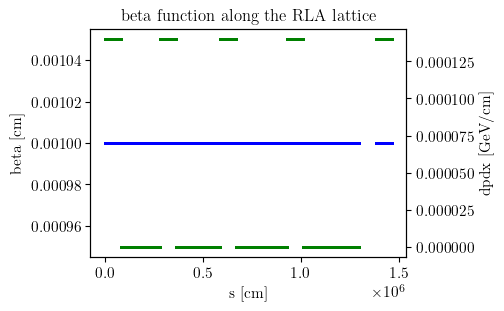

In [29]:

RLA2_numu_noBD = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor='numu',
    direction="right",
    n_evals=1e6,
    )

RLA2_lattice_noBD = lt.create_RLA_lattice(
            name = r"RLA2",
            short_name= "rla2",
            straight_length=829e2,
            n_elements=100_000,
            p0_injection=5.0,
            dp_dx_LA=11.6/829e2,
            beamdiv=1e-3,
            beamdiv_z=1e-2,
            beamsize=1e-2,
            half=False,
            Nmu_per_bunch=2e12,
            beam_dyn=False,
)

RLA2_numu_noBD.decay_muons()
RLA2_numu_noBD.place_muons_on_lattice(lattice=RLA2_lattice_noBD, direction="clockwise")

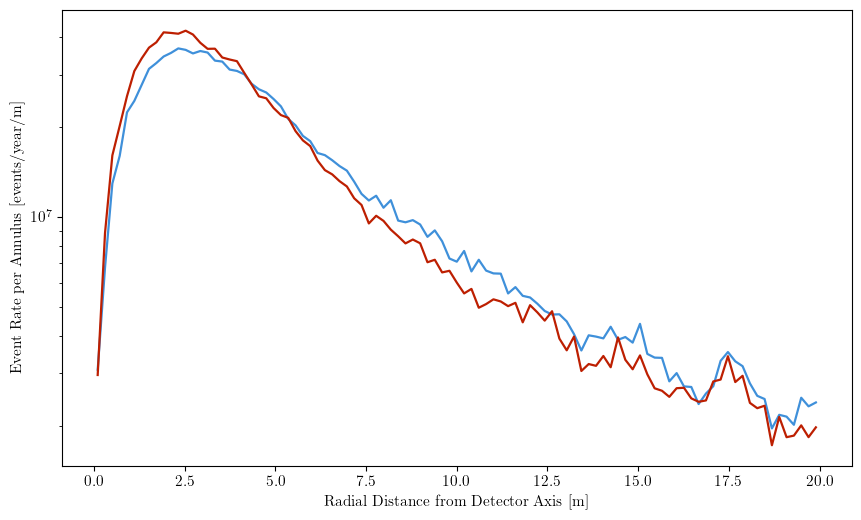

In [30]:
r_edges = np.linspace(0.0, 20e2, 100)

dN_dr_per_year_RLA2 = get_event_rate_at_annuli_event_based(RLA2_numu, det_loc=np.array([0, 0.0, 1500e2]), r_edges=r_edges)
dN_dr_per_year_RLA2_noBD = get_event_rate_at_annuli_event_based(RLA2_numu_noBD, det_loc=np.array([0, 0.0, 1500e2]), r_edges=r_edges)

fig, ax = pt.std_fig(figsize=(10, 6))

r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
ax.plot(r_centers/100.0, dN_dr_per_year_RLA2, lw=1.6)
ax.plot(r_centers/100.0, dN_dr_per_year_RLA2_noBD, lw=1.6)
ax.set_xlabel("Radial Distance from Detector Axis [m]")
ax.set_ylabel("Event Rate per Annulus [events/year/m]")
ax.set_yscale('log')

## Number of $\mu$ decays vs. t

In [31]:

print(sum(combined_numu.weights[combined_numu.s_muon<=160e2,0]))

print(sum(combined_numu.weights[combined_numu.s_muon<=139576.5707264804,0]))

print(sum(combined_numu.weights[:,0]))

80153525837.0757
221228094202.7136
436636662136.22876


In [32]:
# --- helper: cumulative weights vs muon decay time (ns) ---
def plot_cumulative_weights_vs_time(MuC_acc_numu, MuC_acc_nue=None, show_fraction=True, figsize=(5,3)):
    """Plot cumulative sum of weights vs muon decay time (converted to ns).
    If `MuC_acc_nue` is provided it will be plotted alongside `MuC_acc_numu`.
    Returns (fig, ax).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    # primary (numu)
    t1 = np.asarray(MuC_acc_numu.mutimes)
    w1 = np.asarray(MuC_acc_numu.weights)
    if w1.ndim > 1:
        w1 = w1[:, 0]
    order1 = np.argsort(t1)
    t1s = t1[order1]
    cum1 = np.cumsum(w1[order1])
    # optional second (nue)
    if MuC_acc_nue is not None:
        t2 = np.asarray(MuC_acc_nue.mutimes)
        w2 = np.asarray(MuC_acc_nue.weights)
        if w2.ndim > 1:
            w2 = w2[:, 0]
        order2 = np.argsort(t2)
        t2s = t2[order2]
        cum2 = np.cumsum(w2[order2])
    else:
        t2s = None
        cum2 = None
    # plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(1e6 * t1s, cum1, label='numu cumulative', color='C0')
    if cum2 is not None:
        ax.plot(1e6 * t2s, cum2, label='nue cumulative', color='C1')
    ax.set_xlabel('time ($\mu$s)')
    ax.set_ylabel('Number of decays (cumulative)')
    ax.set_title('Number of Decays vs Time')
    ax.grid(True)
    if show_fraction:
        ax2 = ax.twinx()
        total1 = 2e12  # total muons per bunch (or sum of weights if you prefer)
        ax2.plot(1e6 * t1s, cum1 / total1, color='C0', linestyle='--', alpha=0.8, label='numu fraction')
        if cum2 is not None:
            total2 = 2e12  # total muons per bunch (or sum of weights if you prefer)
            ax2.plot(1e6 * t2s, cum2 / total2, color='C1', linestyle='--', alpha=0.8, label='nue fraction')
        ax2.set_ylabel('Fraction of total \n (with respect to Nmu per bunch)')

    fig.tight_layout()

    fig.savefig('plots/num_decays_vs_time.pdf', bbox_inches='tight')
    return fig, ax

# Example calls (uncomment to run)
# plot_cumulative_weights_vs_time(RLA1_numu, RLA1_nue)
# plot_cumulative_weights_vs_time(RLA2_numu, RLA2_nue)
# plot_cumulative_weights_vs_time(PA_numu, PA_nue)

(<Figure size 500x300 with 2 Axes>,
 <Axes: title={'center': 'Number of Decays vs Time'}, xlabel='time ($\\mu$s)', ylabel='Number of decays (cumulative)'>)

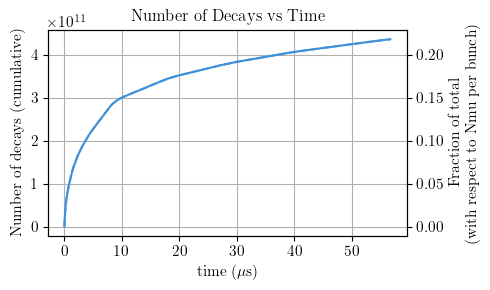

In [33]:
plot_cumulative_weights_vs_time(combined_numu)

In [34]:
def get_event_counts_vs_time(
        self,
        detect_loc,
        nbins=200,
        t_bins=None,
        det_radius=1e2,
    ):
        """Return event counts binned in muon decay time for the given detector locations.

        Args:
            detect_loc: list of (z_det, y_offset) detector tuples (same as get_event_map_fixed_z)
            nbins: number of time bins to use if t_bins is None
            t_bins: optional array of bin edges in seconds
            det_radius: detector acceptance radius (cm)

        Returns:
            (t_centers, counts) where t_centers are bin centres in seconds and counts are
            the predicted number of neutrino interaction events (weights * P_int) in each bin.
        """
        p_dir = self.pnu.to_3D().unit()

        # contributions per simulated decay
        contributions = np.zeros(self.sample_size)

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r2 = x_hit**2 + (y_hit + y_offset) ** 2
            in_acceptance = (t_vals > 0) & (r2 < det_radius**2)

            if not np.any(in_acceptance):
                continue

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            # use same linearized P_int approximation as in get_event_map_fixed_z
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            contributions[in_acceptance] += self.weights[in_acceptance, 0] * P_int

        times = np.asarray(self.mutimes)
        if t_bins is None:
            tmin, tmax = times.min(), times.max()
            t_bins = np.linspace(tmin, tmax, nbins + 1)

        counts, edges = np.histogram(times, bins=t_bins, weights=contributions)
        centers = 0.5 * (edges[:-1] + edges[1:])
        return centers, counts

def plot_event_counts_vs_time(
        self,
        detect_loc,
        nbins=200,
        t_bins=None,
        det_radius=1e2,
        figsize=(6, 3),
        xlabel=None,
        ylabel=None,
    ):
        """Plot predicted neutrino interaction counts vs muon decay time.

        Returns (fig, ax).
        """
        import matplotlib.pyplot as plt

        centers, counts = get_event_counts_vs_time(
            self=self, detect_loc=detect_loc, nbins=nbins, t_bins=t_bins, det_radius=det_radius
        )

        fig, ax = plt.subplots(figsize=figsize)
        ax.step(1e9 * centers, counts, where="mid", color="C0")
        ax.set_xlabel(xlabel or "muon time (ns)")
        ax.set_ylabel(ylabel or "Predicted neutrino events")
        ax.grid(True)
        return fig, ax



(<Figure size 600x300 with 1 Axes>,
 <Axes: xlabel='muon time (ns)', ylabel='Predicted neutrino events'>)

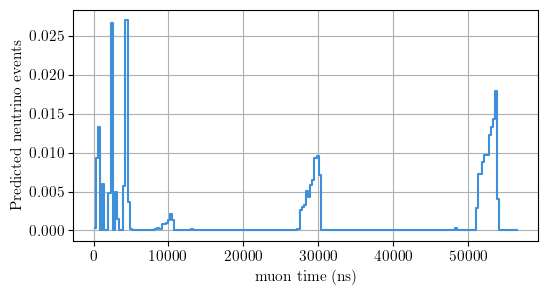

In [35]:
plot_event_counts_vs_time(combined_numu, [(90e2, 0),(120.7921e2-29.11e2, 20e2),(2830.62e2, 40e2)])

In [36]:
def get_event_counts_vs_energy(
        self,
        detect_loc,
        nbins=50,
        e_bins=None,
        log_e=True,
        det_radius=1e2,
    ):
        """Return event counts binned in neutrino energy for the given detector locations.

        Args:
            detect_loc: list of (z_det, y_offset) detector tuples (same as get_event_map_fixed_z)
            nbins: number of energy bins to use if e_bins is None
            e_bins: optional array of bin edges in GeV
            det_radius: detector acceptance radius (cm)

        Returns:
            (e_centers, counts) where e_centers are bin centres in GeV and counts are
            the predicted number of neutrino interaction events (weights * P_int) in each bin.
        """
        p_dir = self.pnu.to_3D().unit()

        # Store neutrino energies and interaction contributions for events in acceptance
        nu_energies = []
        weights_with_interaction = []

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r2 = x_hit**2 + (y_hit + y_offset) ** 2
            in_acceptance = (t_vals > 0) & (r2 < det_radius**2)

            if not np.any(in_acceptance):
                continue

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            # use same linearized P_int approximation as in get_event_map_fixed_z
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            weights_int = self.weights[in_acceptance, 0] * P_int
            nu_energies.extend(self.pnu["E"][in_acceptance])
            weights_with_interaction.extend(weights_int)

        if len(nu_energies) == 0:
            # No events in acceptance, return empty bins
            if e_bins is None:
                if log_e:
                    e_bins = np.logspace(
                        -2, 2, nbins + 1
                    )  # Default energy range 0.01-10 GeV
                else:
                    e_bins = np.linspace(
                        0, 5, nbins + 1
                    )  # Default energy range 0-5 GeV
            counts = np.zeros(len(e_bins) - 1)
            centers = 0.5 * (e_bins[:-1] + e_bins[1:])
            return centers, counts

        nu_energies = np.asarray(nu_energies)
        weights_with_interaction = np.asarray(weights_with_interaction)

        if e_bins is None:
            emin, emax = nu_energies.min(), nu_energies.max()
            e_bins = np.logspace(np.log10(emin), np.log10(emax), nbins + 1)

        counts, edges = np.histogram(
            nu_energies, bins=e_bins, weights=weights_with_interaction
        )
        centers = 0.5 * (edges[:-1] + edges[1:])

        counts *= 5 * np.pi * 1e7  # 5 Hz injection rate * seconds in a year

        dE = np.diff(edges)

        counts /= dE

        return centers, counts

def get_event_counts_vs_energy_srange(
        self,
        s_range,
        nbins=50,
        e_bins=None,
        log_e=True,
    ):
        """
        Compute dN/dE from neutrinos whose muons decayed in a given s_muon region.

        Args:
            s_range: (s_min, s_max) defining accepted muon decay positions along lattice [cm]
            nbins:   number of energy bins if e_bins is None
            e_bins:  optional bin edges [GeV]
            log_e:   whether to use log-spaced bins

        Returns:
            (E_centers, dN/dE)
        """

        s_min, s_max = s_range

        # ---- Acceptance mask determined ONLY by muon decay position ----
        in_acceptance = (self.s_muon >= s_min) & (self.s_muon < s_max)

        if not np.any(in_acceptance):
            # No events → return empty spectrum
            if e_bins is None:
                if log_e:
                    e_bins = np.logspace(-2, 2, nbins + 1)
                else:
                    e_bins = np.linspace(0, 5, nbins + 1)

            centers = 0.5 * (e_bins[:-1] + e_bins[1:])
            counts = np.zeros_like(centers)
            return centers, counts

        # ---- Extract energies and interaction probabilities ----
        nu_E = self.pnu["E"][in_acceptance]  # neutrino energy
        sigma = nu_E * 1e-38  # cm²
        n_target = 1 / 1.67262192e-24  # nucleons/cm³
        P_int = n_target * sigma * 10e2  # linearized

        decay_w = self.weights[in_acceptance, 0]  # decay weights
        weights_int = decay_w * P_int  # weighted contribution

        # ---- Convert to numpy ----
        nu_E = np.asarray(nu_E)
        weights_int = np.asarray(weights_int)

        # ---- Energy binning ----
        if e_bins is None:
            emin, emax = nu_E.min(), nu_E.max()
            if log_e:
                e_bins = np.logspace(np.log10(emin), np.log10(emax), nbins + 1)
            else:
                e_bins = np.linspace(emin, emax, nbins + 1)

        counts, edges = np.histogram(nu_E, bins=e_bins, weights=weights_int)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # ---- Convert to per-year ----
        counts *= 5 * np.pi * 1e7

        # ---- Convert to dN/dE ----
        dE = np.diff(edges)
        counts /= dE

        return centers, counts

def plot_event_counts_vs_energy(
        self,
        detect_loc=None,
        detect=True,
        nbins=50,
        e_bins=None,
        log_e=True,
        det_radius=1e2,
        figsize=(6, 4),
        fig_and_ax=None,
        xlabel=None,
        ylabel=None,
        color="blue",
        label=None,
        s_range=None,
    ):
        """Plot predicted neutrino interaction counts vs neutrino energy.

        Returns (fig, ax).
        """
        import matplotlib.pyplot as plt
        from scipy.interpolate import UnivariateSpline as uspline

        if detect:
            centers, counts = get_event_counts_vs_energy(
                self=self,
                detect_loc=detect_loc,
                nbins=nbins,
                e_bins=e_bins,
                log_e=log_e,
                det_radius=det_radius,
            )
        else:
            centers, counts = get_event_counts_vs_energy_srange(
                self=self, s_range=s_range, nbins=nbins, e_bins=e_bins, log_e=log_e
            )

        if fig_and_ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig, ax = fig_and_ax

        # Ensure arrays
        centers = np.asarray(centers)
        counts = np.asarray(counts)

        # Filter out non-positive values since log scale cannot display them
        mask = (centers > 0) & (counts > 0)
        if np.any(mask):
            # plot only positive bins on log-log axes
            (line,) = ax.step(centers[mask], counts[mask], where="mid")
            ax.set_xscale("log")
            ax.set_yscale("log")
        else:
            # fallback to linear plot if no positive bins
            (line,) = ax.step(centers, counts, where="mid")
            import warnings

            warnings.warn(
                "No positive (center,count) pairs found for log-log plot; using linear scales instead."
            )

        line.set_color(color)
        if label:
            line.set_label(label)

        ax.set_xlabel(xlabel or "Neutrino Energy (GeV)")
        ax.set_ylabel(ylabel or "Predicted neutrino events")
        ax.grid(True, which="both", ls="--", alpha=0.5)

        return fig, ax, label

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Neutrino Energy (GeV)', ylabel='Predicted neutrino events'>,
 None)

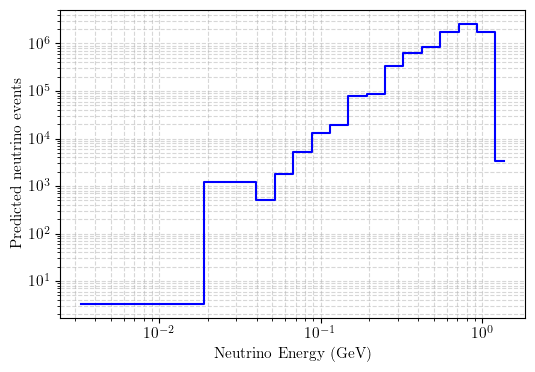

In [37]:
plot_event_counts_vs_energy(combined_numu, [(90e2, 0)], e_bins=np.geomspace(1e-3,2,30))

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Neutrino Energy (GeV)', ylabel='Predicted neutrino events'>,
 None)

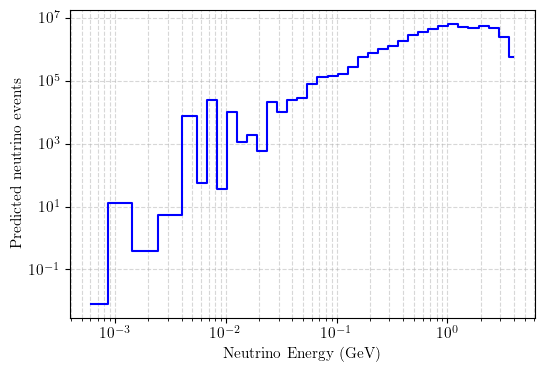

In [38]:
plot_event_counts_vs_energy(combined_numu,[(120.7921e2-29.11e2, 20e2)])

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='Neutrino Energy (GeV)', ylabel='dN/dE (per year)'>,
 None)

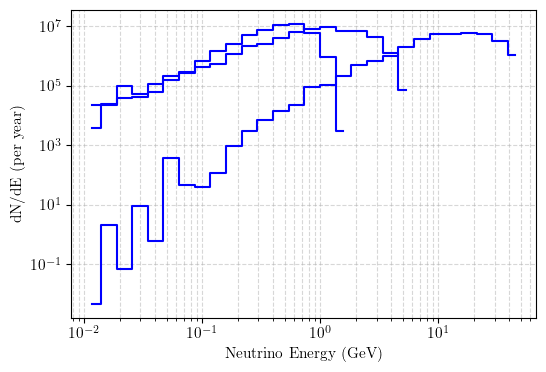

In [39]:
fig, ax, _ = plot_event_counts_vs_energy(combined_numu,[(2835.62e2, 40e2)], det_radius=5e2, e_bins=np.geomspace(1e-2, 70, 30))
plot_event_counts_vs_energy(combined_numu, [(91.6821e2, 20e2)], det_radius=1.5e2, e_bins=np.geomspace(1e-2, 70, 30), fig_and_ax=(fig, ax))
plot_event_counts_vs_energy(combined_numu, [(85e2, 0)], det_radius=5e2, e_bins=np.geomspace(1e-2, 70, 30), fig_and_ax=(fig, ax),ylabel="dN/dE (per year)")


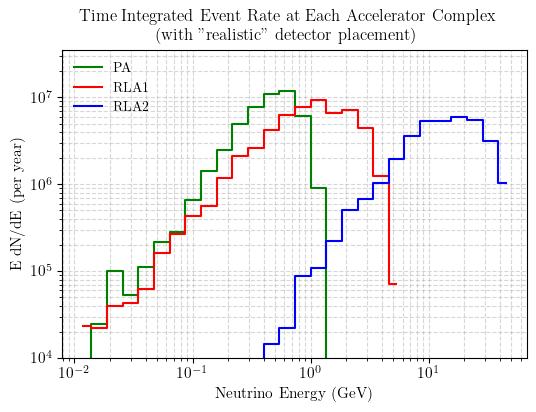

In [40]:
fig, ax, _ = plot_event_counts_vs_energy(
    combined_numu,
    detect_loc=[(85e2, 0)],
    det_radius=5e2,
    e_bins=np.geomspace(1e-2, 70, 30),
    color="green",
    label="PA",
)

plot_event_counts_vs_energy(
    combined_numu,
    detect_loc=[(91.6821e2, 20e2)],
    det_radius=1.5e2,
    e_bins=np.geomspace(1e-2, 70, 30),
    fig_and_ax=(fig, ax),
    color="red",
    label="RLA1"
)


plot_event_counts_vs_energy(
    combined_numu,
    detect_loc=[(2835.62e2, 40e2)],
    det_radius=5e2,
    e_bins=np.geomspace(1e-2, 70, 30),
    fig_and_ax=(fig, ax),
    color="blue",
    label="RLA2",
    ylabel="E dN/dE (per year)"
)


ax.legend()
ax.set_ylim(bottom=1e4) 
fig.suptitle("Time Integrated Event Rate at Each Accelerator Complex\n (with \"realistic\" detector placement)")
plt.show()

fig.savefig('plots/event_rate_spectrum.pdf', bbox_inches='tight')

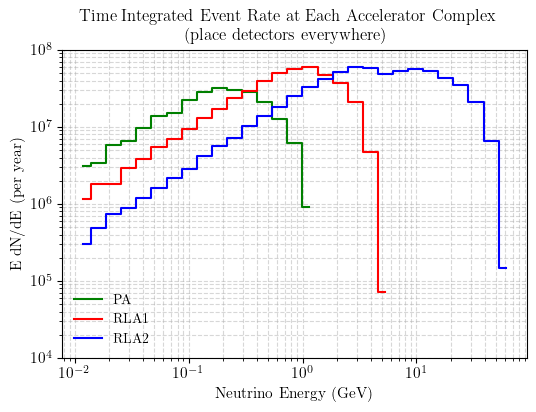

In [41]:
fig, ax, _ = plot_event_counts_vs_energy(
    combined_numu,
    detect=False,
    e_bins=np.geomspace(1e-2, 70, 30),
    s_range=(0,160e2),
    color="green",
    label="PA"
)

plot_event_counts_vs_energy(
    combined_numu,
    detect=False,
    e_bins=np.geomspace(1e-2, 70, 30),
    s_range=(160e2,1.4e5),
    fig_and_ax=(fig, ax),
    color="red",
    label="RLA1"
)

plot_event_counts_vs_energy(
    combined_numu,
    detect=False,
    e_bins=np.geomspace(1e-2, 70, 30),
    s_range=(1.4e5,1.699697e6),
    fig_and_ax=(fig, ax),
    color="blue",
    label="RLA2",
    ylabel="E dN/dE (per year)"
)

ax.legend()
ax.set_ylim(1e4, 1e8)
fig.suptitle("Time Integrated Event Rate at Each Accelerator Complex\n (place detectors everywhere)")
plt.show()

fig.savefig('plots/event_rate_spectrum_all.pdf', bbox_inches='tight')

## Compare # of events vs. distance

In [42]:
from mint import const


def get_event_counts_vs_distance(
        self,
        y_offset,
        z_range,
        nbins=200,
        det_radius=5e2,
    ):
    z_start, z_end = z_range
    z_bins = np.geomspace(z_start, z_end, nbins + 1)
    z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
    counts = np.zeros(nbins)

    p_dir = self.pnu.to_3D().unit()

    for i, z_det in enumerate(z_centers):
        t_vals = (z_det - self.pos["z"]) / p_dir["z"]
        x_hit = self.pos["x"] + t_vals * p_dir["x"]
        y_hit = self.pos["y"] + t_vals * p_dir["y"]

        r2 = x_hit**2 + (y_hit + y_offset) ** 2
        in_acceptance = (t_vals > 0) & (r2 < det_radius**2)

        if not np.any(in_acceptance):
            continue

        #DUNE far detector specs: 40 kton fiducial mass, 58.2 m length, LAr density 1.395 g/cm^3
        detector_length_cm = 58.2e2  
        rho_g_cm3 = 1.395 #LAr density g/cm^3

        nucleon_column_density = rho_g_cm3 * detector_length_cm / const.m_proton_in_g
        sigma = self.pnu["E"][in_acceptance] * 1e-38
        P_int = nucleon_column_density * sigma

        counts[i] = np.sum(self.weights[in_acceptance, 0] * P_int)

    # Scale to per year
    counts *= 5 * np.pi * 1e7

    z_centers /= 1e2 #convert to m

    return z_centers, counts

def plot_event_counts_vs_distance(
        self,
        y_offset,
        z_range,
        nbins=200,
        det_radius=5e2,
        figsize=(6, 3),
        fig_and_ax=None,
        xlabel=None,
        ylabel=None,
        title=None,
        label=None,
        color="blue",
    ):
    import matplotlib.pyplot as plt

    z_centers, counts = get_event_counts_vs_distance(
        self=self, y_offset=y_offset, z_range=z_range, nbins=nbins, det_radius=det_radius
    )

    if fig_and_ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig, ax = fig_and_ax

    line, = ax.plot(z_centers, counts)
    ax.set_xlabel(xlabel or "Detector Z position (m)")
    ax.set_ylabel(ylabel or "Predicted neutrino events per year")
    ax.grid(True)

    if title:
        ax.set_title(title)

    line.set_color(color)
    if label:
        line.set_label(label)

    return fig, ax, label

(<Figure size 600x300 with 1 Axes>,
 <Axes: title={'center': 'RLA2 Detector Event Counts vs Distance'}, xlabel='Detector Z position (m)', ylabel='Predicted neutrino events per year'>,
 None)

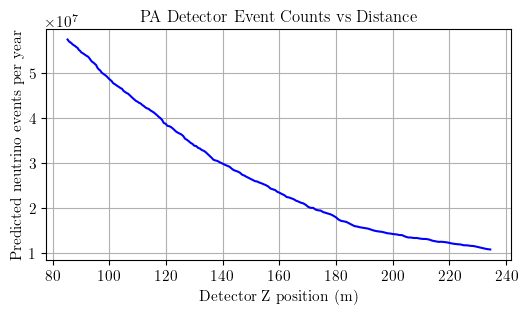

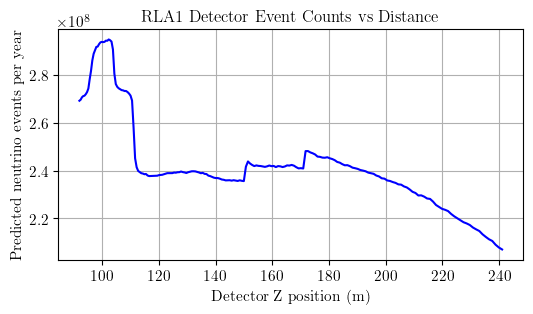

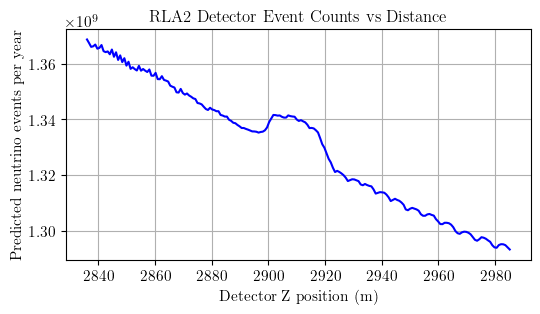

In [43]:
plot_event_counts_vs_distance(combined_numu, 0, (85e2, 235e2),title="PA Detector Event Counts vs Distance") #150 m detector position range

plot_event_counts_vs_distance(combined_numu, 20e2, (91.6821e2,241.6821e2),title="RLA1 Detector Event Counts vs Distance")

plot_event_counts_vs_distance(combined_numu, 40e2, (2835.62e2,2985.62e2),title="RLA2 Detector Event Counts vs Distance")

In [114]:
def plot_power_law(
    fig_and_ax,
    initial_point,
    x_range
):
    import matplotlib.pyplot as plt
    fig, ax = fig_and_ax
    x0, y0 = initial_point
    x_vals = np.array(x_range)
    y_vals = y0 * (x0 / x_vals)**2
    ax.plot(x_vals, y_vals, linestyle='--', color='black', label=r'$1/r^2$')
    return fig, ax

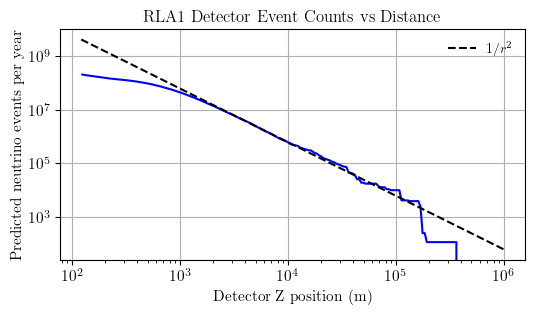

In [ ]:
det_radius = 2*np.sqrt(12e2*14e2/np.pi)

fig, ax, _ = plot_event_counts_vs_distance(RLA1_numu, 0, (121e2,1e8), det_radius=det_radius, title="RLA1 Detector Event Counts vs Distance")
ax.set_yscale('log')
ax.set_xscale('log')

plot_power_law(
    fig_and_ax=(fig, ax),
    initial_point=(4611.960489667486, 2868029.0606408943),
    x_range=range(121,1000000)
)

#Webplotdigitizer says the intersection point is at (1753.628267547892, 18013207.603121586)
ax.legend()
# ax.set_ylim(1e0, 1e6)
plt.show()

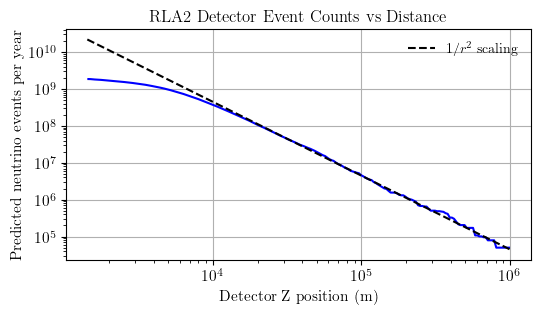

In [ ]:
fig, ax, _ = plot_event_counts_vs_distance(RLA2_numu, 0, (1430.53e2,1e8),det_radius=det_radius,title="RLA2 Detector Event Counts vs Distance")
ax.set_yscale('log')
ax.set_xscale('log')

plot_power_law(
    fig_and_ax=(fig, ax),
    initial_point=(33142.79704646556, 40798505.78829481),
    x_range=range(1430,1000000)
)

#webplotdigitizer says the intersection point is at (13935.17663686254, 223781057.36348823)

ax.legend()
# ax.set_ylim(1e0, 1e8)
plt.show()

## Compare detector sizes

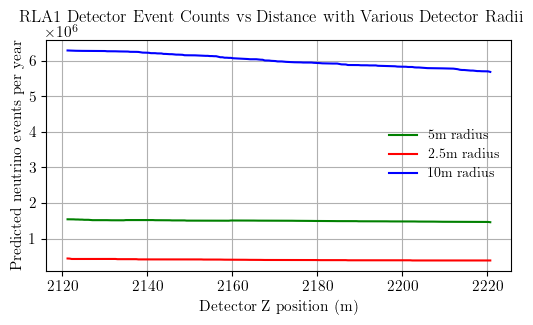

In [46]:
fig, ax, _ = plot_event_counts_vs_distance(
    RLA1_numu,
    y_offset=0,
    z_range=(2121e2,2221e2),
    color="green",
    label="5m radius",
)

plot_event_counts_vs_distance(
    RLA1_numu,
    y_offset=0,
    z_range=(2121e2,2221e2),
    det_radius=2.5e2,
    fig_and_ax=(fig, ax),
    label="2.5m radius",
    color="red",
)

plot_event_counts_vs_distance(
    RLA1_numu,
    y_offset=0,
    z_range=(2121e2,2221e2),
    color="blue",
    det_radius=10e2,
    fig_and_ax=(fig, ax),
    label="10m radius"
)

ax.legend()
fig.suptitle("RLA1 Detector Event Counts vs Distance with Various Detector Radii")
plt.show()

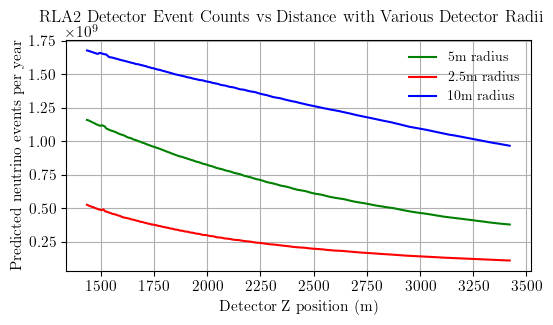

In [47]:
fig, ax, _ = plot_event_counts_vs_distance(
    RLA2_numu,
    y_offset=0,
    z_range=(1430.53e2,3430.53e2),
    color="green",
    label="5m radius",
)

plot_event_counts_vs_distance(
    RLA2_numu,
    y_offset=0,
    z_range=(1430.53e2,3430.53e2),
    det_radius=2.5e2,
    fig_and_ax=(fig, ax),
    label="2.5m radius",
    color="red",
)

plot_event_counts_vs_distance(
    RLA2_numu,
    y_offset=0,
    z_range=(1430.53e2,3430.53e2),
    color="blue",
    det_radius=10e2,
    fig_and_ax=(fig, ax),
    label="10m radius"
)

ax.legend()
fig.suptitle("RLA2 Detector Event Counts vs Distance with Various Detector Radii")
plt.show()

In [48]:
z_centers, counts =get_event_counts_vs_distance(
        RLA2_numu,
        y_offset=0,
        z_range=(1430.53e2,3430.53e2),
    )

print(counts[np.where(z_centers == 1505.53)])

[]


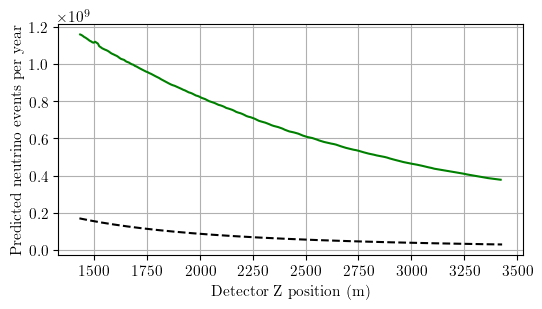

In [50]:
fig, ax, _ = plot_event_counts_vs_distance(
    RLA2_numu,
    y_offset=0,
    z_range=(1430.53e2,3430.53e2),
    color="green",
    label="5m radius",
)

plot_power_law(
    fig_and_ax=(fig, ax),
    initial_point=(1505.53, 1.53469786e+08),
    x_range=range(1430,3431)
)

plt.show()

In [51]:
z_centers, counts =get_event_counts_vs_distance(
        RLA1_numu,
        y_offset=0,
        z_range=(121e2,221e2),
    )

print(z_centers[0])
print(counts[np.where((z_centers >= 121)&(z_centers <= 121.5))])

121.18249225985255
[1.30005587e+08]


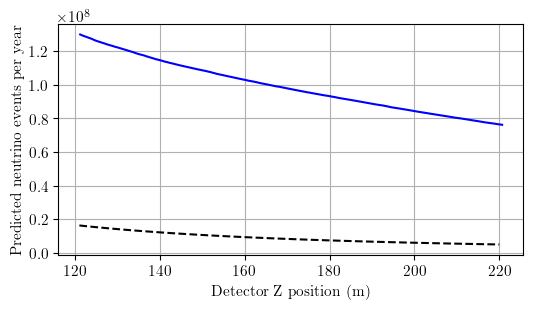

In [52]:
fig, ax, _ = plot_event_counts_vs_distance(
    RLA1_numu,
    y_offset=0,
    z_range=(121e2,221e2),
    color="blue",
    label="5m radius",
)

plot_power_law(
    fig_and_ax=(fig, ax),
    initial_point=(121.25, 16163561.60363407),
    x_range=range(121,221)
)

plt.show()

## Get Energy ranges

In [53]:
def get_energy_range(
        self,
        detect_loc,
        det_radius=5e2,
    ):
        
        p_dir = self.pnu.to_3D().unit()

        # Store neutrino energies and interaction contributions for events in acceptance
        nu_energies = []

        for t in detect_loc:
            z_det, y_offset = t

            t_vals = (z_det - self.pos["z"]) / p_dir["z"]
            x_hit = self.pos["x"] + t_vals * p_dir["x"]
            y_hit = self.pos["y"] + t_vals * p_dir["y"]

            r2 = x_hit**2 + (y_hit + y_offset) ** 2
            in_acceptance = (t_vals > 0) & (r2 < det_radius**2)

            if not np.any(in_acceptance):
                continue

            sigma = self.pnu["E"][in_acceptance] * 1e-38
            # use same linearized P_int approximation as in get_event_map_fixed_z
            P_int = (1 / 1.67262192e-24) * sigma * 10e2

            nu_energies.extend(self.pnu["E"][in_acceptance])

        nu_energies = np.asarray(nu_energies)

        min_E = nu_energies.min()
        max_E = nu_energies.max()

        return min_E, max_E

In [54]:
def get_energy_srange(
        self,
        s_range,
):
        s_min, s_max = s_range

        # ---- Acceptance mask determined ONLY by muon decay position ----
        in_acceptance = (self.s_muon >= s_min) & (self.s_muon < s_max)

        # ---- Extract energies and interaction probabilities ----
        nu_E = self.pnu["E"][in_acceptance]  # neutrino energy
        sigma = nu_E * 1e-38  # cm²
        n_target = 1 / 1.67262192e-24  # nucleons/cm³
        P_int = n_target * sigma * 10e2  # linearized

        # ---- Convert to numpy ----
        nu_E = np.asarray(nu_E)

        return nu_E.min(), nu_E.max()

In [55]:
PA_min, PA_max = get_energy_range(combined_numu, [(85e2, 0)], det_radius=5e2)

RLA1_min, RLA1_max = get_energy_range(combined_numu, [(91.6821e2, 20e2)], det_radius=5e2)

RLA2_min, RLA2_max = get_energy_range(combined_numu, [(2835.62e2, 40e2)], det_radius=5e2)

mins_and_maxes = [PA_min, PA_max, RLA1_min, RLA1_max, RLA2_min, RLA2_max]

print(mins_and_maxes)

for i in range(len(mins_and_maxes)):
    osc_length = 2.473 * mins_and_maxes[i]/(10**-4)
    print(osc_length)

[np.float64(0.00027230813844390545), np.float64(1.7440948221287327), np.float64(1.1884831097991998e-05), np.float64(5.032650959043884), np.float64(0.0009434612626597213), np.float64(51.34557489296065)]
6.734180263717781
43131.46495124355
0.2939118730533421
124457.45821715525
23.331797025574904
1269776.0671029168


In [56]:
PA_min, PA_max = get_energy_srange(combined_numu, (0,160e2)) #PA

RLA1_min, RLA1_max = get_energy_srange(combined_numu, (160e2,139576.5707264804)) #RLA1

RLA2_min, RLA2_max = get_energy_srange(combined_numu, (139576.5707264804,1699698.1473337878)) #RLA2

mins_and_maxes = [PA_min, PA_max, RLA1_min, RLA1_max, RLA2_min, RLA2_max]

print(mins_and_maxes)

for i in range(len(mins_and_maxes)):
    osc_length = 2.473 * mins_and_maxes[i]/(10**-4)
    print(osc_length)

[np.float64(2.2585859569646833e-05), np.float64(1.2045202262723134), np.float64(3.974448361594743e-06), np.float64(4.751363389870685), np.float64(9.452184280936068e-06), np.float64(62.686991855618395)]
0.5585483071573661
29787.785195714307
0.09828810798223798
117501.21663150203
0.23375251726754892
1550249.3085894429


## Plot based on which pass

In [57]:
def get_which_pass_from_lattice(lattice):
    """
    Get s values and which_pass values from a lattice's which_pass interpolating function.
    
    Args:
        lattice: A Lattice object with which_pass interpolating function
        
    Returns:
        (s_array, which_pass_array): Arrays of s values and corresponding pass numbers
    """
    # Create a dense sampling of the lattice
    u_vals = np.linspace(0, 1, 10000)
    s_vals = lattice.s(u_vals)
    which_pass_vals = lattice.which_pass(u_vals)
    
    return s_vals, which_pass_vals


def plot_passes(lattice, figsize=(10, 4)):
    """
    Plot s value vs which_pass for an RLA lattice.
    
    Args:
        lattice: A Lattice object with which_pass interpolating function
        figsize: Figure size
        
    Returns:
        (fig, ax)
    """
    s_vals, which_pass_vals = get_which_pass_from_lattice(lattice)
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(s_vals/1e5, which_pass_vals, s=1, alpha=0.5)
    ax.set_xlabel("Arc length s [km]")
    ax.set_ylabel("Pass number")
    ax.set_title(f"Pass Number vs Arc Length for {lattice.name}")
    ax.grid(True, alpha=0.3)
    
    return fig, ax


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Pass Number vs Arc Length for RLA1'}, xlabel='Arc length s [km]', ylabel='Pass number'>)

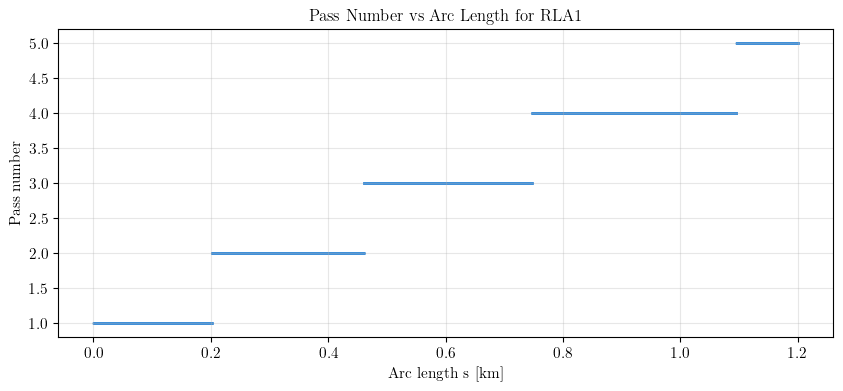

In [58]:
plot_passes(RLA1_lattice)


In [97]:
def get_event_counts_vs_energy_pass(
        self,
        lattice,
        target_pass,
        detect=False,
        detect_loc=None,
        det_radius=1e2,
        nbins=50,
        e_bins=None,
        log_e=True,
    ):
        """
        Compute dN/dE from neutrinos whose muons decayed in a given pass number.

        Args:
            lattice: Lattice object with which_pass interpolating function
            target_pass: which pass number (1-5) to filter by
            detect: whether to apply detector-based filtering
            detect_loc: list of (z_det, y_offset) detector tuples if detect=True
            det_radius: detector acceptance radius (cm)
            nbins:   number of energy bins if e_bins is None
            e_bins:  optional bin edges [GeV]
            log_e:   whether to use log-spaced bins

        Returns:
            (E_centers, dN/dE)
        """

        # Get which pass each muon decay occurred in
        # Convert s to normalized coordinate u
        u_muon = self.s_muon / np.max(self.s_in_turn)
        which_pass_vals = lattice.which_pass(u_muon)
        
        # ---- Acceptance mask determined by pass number ----
        in_acceptance = (which_pass_vals == target_pass)

        # ---- If detect=True, also apply detector-based filtering ----
        if detect and detect_loc is not None:
            p_dir = self.pnu.to_3D().unit()
            detector_acceptance = np.zeros(len(self.s_muon), dtype=bool)
            
            for t in detect_loc:
                z_det, y_offset = t
                
                t_vals = (z_det - self.pos["z"]) / p_dir["z"]
                x_hit = self.pos["x"] + t_vals * p_dir["x"]
                y_hit = self.pos["y"] + t_vals * p_dir["y"]
                
                r2 = x_hit**2 + (y_hit + y_offset) ** 2
                detector_acceptance |= (t_vals > 0) & (r2 < det_radius**2)
            
            # Combine pass and detector acceptance
            in_acceptance = in_acceptance & detector_acceptance

        if not np.any(in_acceptance):
            # No events in this pass/detector → return empty spectrum
            if e_bins is None:
                if log_e:
                    e_bins = np.logspace(-2, 2, nbins + 1)
                else:
                    e_bins = np.linspace(0, 5, nbins + 1)

            centers = 0.5 * (e_bins[:-1] + e_bins[1:])
            counts = np.zeros_like(centers)
            return centers, counts

        # ---- Extract energies and interaction probabilities ----
        nu_E = self.pnu["E"][in_acceptance]  # neutrino energy
        sigma = nu_E * 1e-38  # cm²
        n_target = 1 / 1.67262192e-24  # nucleons/cm³
        P_int = n_target * sigma * 10e2  # linearized

        decay_w = self.weights[in_acceptance, 0]  # decay weights
        weights_int = decay_w * P_int  # weighted contribution

        # ---- Convert to numpy ----
        nu_E = np.asarray(nu_E)
        weights_int = np.asarray(weights_int)

        # ---- Energy binning ----
        if e_bins is None:
            emin, emax = nu_E.min(), nu_E.max()
            if log_e:
                e_bins = np.logspace(np.log10(emin), np.log10(emax), nbins + 1)
            else:
                e_bins = np.linspace(emin, emax, nbins + 1)

        counts, edges = np.histogram(nu_E, bins=e_bins, weights=weights_int)
        centers = 0.5 * (edges[:-1] + edges[1:])

        # ---- Convert to per-year ----
        counts *= 5 * np.pi * 1e7

        # ---- Convert to dN/dE ----
        dE = np.diff(edges)
        counts /= dE

        return centers, counts

def plot_event_counts_vs_energy_pass(
        self,
        lattice,
        target_pass,
        detect=False,
        detect_loc=None,
        det_radius=1e2,
        nbins=50,
        e_bins=None,
        log_e=True,
        figsize=(6, 4),
        fig_and_ax=None,
        xlabel=None,
        ylabel=None,
        color="blue",
        label=None,
    ):
        """Plot predicted neutrino interaction counts vs neutrino energy.

        Returns (fig, ax).
        """
        import matplotlib.pyplot as plt
        from scipy.interpolate import UnivariateSpline as uspline

        centers, counts = get_event_counts_vs_energy_pass(
            self=self, lattice=lattice, target_pass=target_pass, detect=detect, detect_loc=detect_loc, det_radius=det_radius, nbins=nbins, e_bins=e_bins, log_e=log_e
        )

        if fig_and_ax is None:
            fig, ax = plt.subplots(figsize=figsize)
        else:
            fig, ax = fig_and_ax

        # Ensure arrays
        centers = np.asarray(centers)
        counts = np.asarray(counts)

        # Filter out non-positive values since log scale cannot display them
        mask = (centers > 0) & (counts > 0)
        if np.any(mask):
            # plot only positive bins on log-log axes
            (line,) = ax.step(centers[mask], counts[mask], where="mid")
            ax.set_yscale("log")
            if log_e:
                ax.set_xscale("log")
        else:
            # fallback to linear plot if no positive bins
            (line,) = ax.step(centers, counts, where="mid")
            import warnings

            warnings.warn(
                "No positive (center,count) pairs found for log-log plot; using linear scales instead."
            )

        line.set_color(color)
        if label:
            line.set_label(label)

        ax.set_xlabel(xlabel or "Neutrino Energy (GeV)")
        ax.set_ylabel(ylabel or "Predicted neutrino events")
        ax.grid(True, which="both", ls="--", alpha=0.5)

        return fig, ax, label

In [60]:
def get_max_event_rate_and_energy(centers, counts):
    """
    Find the maximum event rate and corresponding neutrino energy.
    
    Returns:
        (max_count, max_energy)
    """
    max_idx = np.argmax(counts)
    return counts[max_idx], centers[max_idx]

In [61]:

# Usage
for i in range(1, 6):
    if i % 2 == 0:
        centers, counts = get_event_counts_vs_energy_pass(RLA1_numu, RLA1_lattice, target_pass=i, detect=True, detect_loc=[(-13589,0)], e_bins=np.geomspace(1e-2, 70, 30),)
    else:
        centers, counts = get_event_counts_vs_energy_pass(RLA1_numu, RLA1_lattice, target_pass=i, detect=True, detect_loc=[(12579,0)], e_bins=np.geomspace(1e-2, 70, 30),)
    
    max_count, max_energy = get_max_event_rate_and_energy(centers, counts)
    print(f"Max: {max_count:.2e} at E = {max_energy:.4f} GeV")

Max: 2.08e+05 at E = 1.1486 GeV
Max: 2.81e+05 at E = 1.5587 GeV
Max: 5.16e+05 at E = 2.1152 GeV
Max: 5.73e+05 at E = 2.8704 GeV
Max: 3.75e+05 at E = 2.8704 GeV


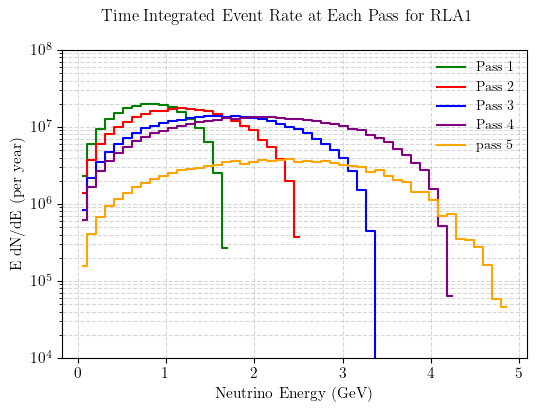

In [77]:
fig, ax, _ = plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=1,
    # e_bins=np.geomspace(1e-2, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    color="green",
    label="Pass 1"
)

plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=2,
    # e_bins=np.geomspace(1e-2, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="red",
    label="Pass 2"
)

plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=3,
    # e_bins=np.geomspace(1e-2, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="blue",
    label="Pass 3"
)

plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=4,
    # e_bins=np.geomspace(1e-2, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="purple",
    label="Pass 4"
)

plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=5,
    # e_bins=np.geomspace(1e-2, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="orange",
    label="pass 5",
    ylabel="E dN/dE (per year)"
)

ax.legend()
ax.set_ylim(1e4, 1e8)
fig.suptitle("Time Integrated Event Rate at Each Pass for RLA1")
plt.show()

#fig.savefig('plots/event_rate_spectrum_all.pdf', bbox_inches='tight')

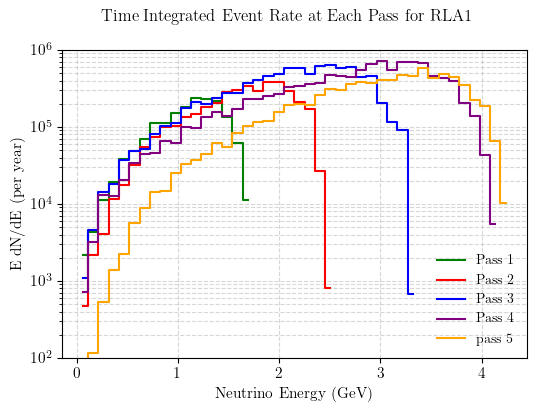

In [83]:
fig, ax, _ = plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=1,
    detect=True,
    detect_loc=[(12579,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    color="green",
    label="Pass 1"
)

plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=2,
    detect=True,
    detect_loc=[(-13589,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="red",
    label="Pass 2"
)

plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=3,
    detect=True,
    detect_loc=[(12579,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="blue",
    label="Pass 3"
)

plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=4,
    detect=True,
    detect_loc=[(-13589,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="purple",
    label="Pass 4"
)

plot_event_counts_vs_energy_pass(
    RLA1_numu,
    RLA1_lattice,
    target_pass=5,
    detect=True,
    detect_loc=[(12579,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-2, 5, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="orange",
    label="pass 5",
    ylabel="E dN/dE (per year)"
)

ax.legend()
ax.set_ylim(1e2, 1e6)
fig.suptitle("Time Integrated Event Rate at Each Pass for RLA1")
plt.show()

#fig.savefig('plots/event_rate_spectrum_all.pdf', bbox_inches='tight')

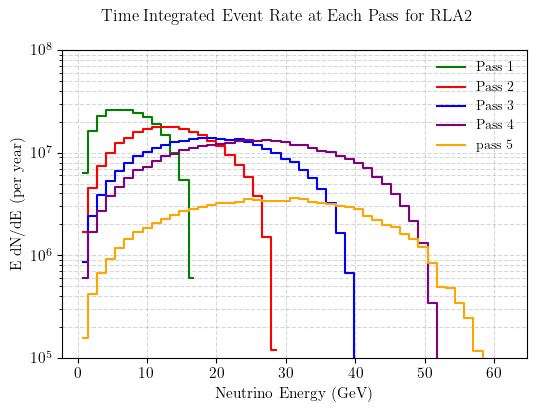

In [85]:
fig, ax, _ = plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=1,
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    color="green",
    label="Pass 1"
)

plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=2,
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="red",
    label="Pass 2"
)

plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=3,
    # e_bins=np.geomspace(1e-2, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="blue",
    label="Pass 3"
)

plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=4,
    # e_bins=np.geomspace(1e-2, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="purple",
    label="Pass 4"
)

plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=5,
    # e_bins=np.geomspace(1e-2, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="orange",
    label="pass 5",
    ylabel="E dN/dE (per year)"
)

ax.legend()
ax.set_ylim(1e5, 1e8)
fig.suptitle("Time Integrated Event Rate at Each Pass for RLA2")
plt.show()

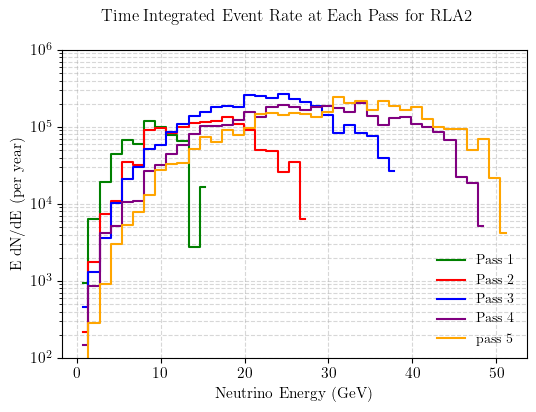

In [88]:
fig, ax, _ = plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=1,
    detect=True,
    detect_loc=[(143552,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    color="green",
    label="Pass 1"
)

plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=2,
    detect=True,
    detect_loc=[(-155510,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="red",
    label="Pass 2"
)

plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=3,
    detect=True,
    detect_loc=[(143552,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="blue",
    label="Pass 3"
)

plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=4,
    detect=True,
    detect_loc=[(-155510,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="purple",
    label="Pass 4"
)

plot_event_counts_vs_energy_pass(
    RLA2_numu,
    RLA2_lattice,
    target_pass=5,
    detect=True,
    detect_loc=[(143552,0)],
    # e_bins=np.geomspace(1e-1, 70, 30),
    e_bins=np.linspace(1e-1, 65, 50),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="orange",
    label="pass 5",
    ylabel="E dN/dE (per year)"
)

ax.legend()
ax.set_ylim(1e2, 1e6)
fig.suptitle("Time Integrated Event Rate at Each Pass for RLA2")
plt.show()

## Plot energy passes for the total combined lattice

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Pass Number vs Arc Length for PA+RLA1+RLA2'}, xlabel='Arc length s [km]', ylabel='Pass number'>)

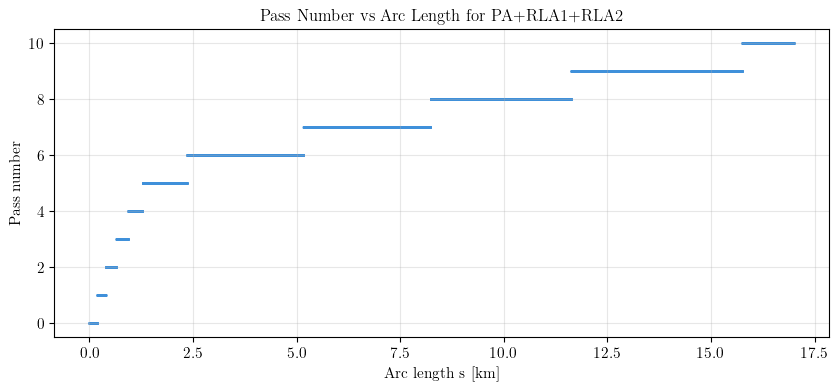

In [66]:
plot_passes(combined_lattice)

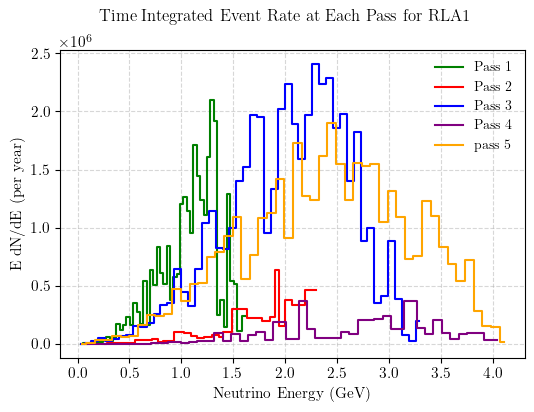

In [116]:
shifted_detect_loc_RLA1 = 1753.628267547892

fig, ax, _ = plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=1,
    detect=True,
    detect_loc=[(91.6821e2+shifted_detect_loc_RLA1, 20e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    color="green",
    label="Pass 1"
)

plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=2,
    detect=True,
    detect_loc=[(91.6821e2-26168-shifted_detect_loc_RLA1, 20e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="red",
    label="Pass 2"
)

plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=3,
    detect=True,
    detect_loc=[(91.6821e2+shifted_detect_loc_RLA1, 20e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="blue",
    label="Pass 3"
)

plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=4,
    detect=True,
    detect_loc=[(91.6821e2-26168-shifted_detect_loc_RLA1, 20e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="purple",
    label="Pass 4"
)

plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=5,
    detect=True,
    detect_loc=[(91.6821e2+shifted_detect_loc_RLA1, 20e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="orange",
    label="pass 5",
    ylabel="E dN/dE (per year)"
)

ax.legend()
# ax.set_ylim(1e2, 1e7)
fig.suptitle("Time Integrated Event Rate at Each Pass for RLA1")
plt.yscale("linear")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

#fig.savefig('plots/event_rate_spectrum_all.pdf', bbox_inches='tight')

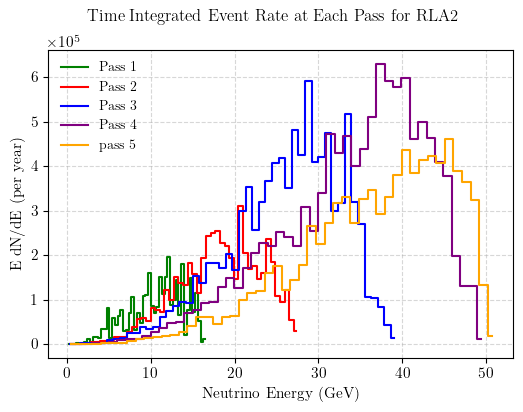

In [117]:
shifted_detect_loc_RLA2 = 13935.17663686254

fig, ax, _ = plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=6,
    detect=True,
    detect_loc=[(2835.62e2+shifted_detect_loc_RLA2, 40e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    color="green",
    label="Pass 1"
)

plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=7,
    detect=True,
    detect_loc=[(2835.62e2-299062-shifted_detect_loc_RLA2, 40e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="red",
    label="Pass 2"
)

plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=8,
    detect=True,
    detect_loc=[(2835.62e2+shifted_detect_loc_RLA2, 40e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="blue",
    label="Pass 3"
)

plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=9,
    detect=True,
    detect_loc=[(2835.62e2-299062-shifted_detect_loc_RLA2, 40e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="purple",
    label="Pass 4"
)

plot_event_counts_vs_energy_pass(
    combined_numu,
    combined_lattice,
    target_pass=10,
    detect=True,
    detect_loc=[(2835.62e2+shifted_detect_loc_RLA2, 40e2)],
    #e_bins=np.geomspace(1e-1, 70, 30),
    log_e=False,
    fig_and_ax=(fig, ax),
    color="orange",
    label="pass 5",
    ylabel="E dN/dE (per year)"
)

ax.legend()
#ax.set_ylim(1e4, 1e8)
fig.suptitle("Time Integrated Event Rate at Each Pass for RLA2")
plt.yscale("linear")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

In [69]:
max_E = []

for i in range(1,6):
    if i % 2 == 0:
        centers, counts = get_event_counts_vs_energy_pass(combined_numu, combined_lattice, target_pass=i, detect=True, detect_loc=[(91.6821e2-26168, 20e2)],log_e=False,)
    else:
        centers, counts = get_event_counts_vs_energy_pass(combined_numu, combined_lattice, target_pass=i, detect=True, detect_loc=[(91.6821e2, 20e2)],log_e=False,)
    
    max_count, max_energy = get_max_event_rate_and_energy(centers, counts)
    max_E.append(max_energy)
    print(f"Pass: {i}, Max: {max_count:.2e} at E = {max_energy:.4f} GeV")

for i in range(6, 11):
    if i % 2 == 0:
        centers, counts = get_event_counts_vs_energy_pass(combined_numu, combined_lattice, target_pass=i, detect=True, detect_loc=[(2835.62e2, 40e2)],log_e=False,)
    else:
        centers, counts = get_event_counts_vs_energy_pass(combined_numu, combined_lattice, target_pass=i, detect=True, detect_loc=[(2835.62e2-299062, 40e2)], log_e=False)
    
    max_count, max_energy = get_max_event_rate_and_energy(centers, counts)
    max_E.append(max_energy)
    print(f"Pass: {i}, Max: {max_count:.2e} at E = {max_energy:.4f} GeV")

Pass: 1, Max: 4.62e+06 at E = 1.1600 GeV
Pass: 2, Max: 7.84e+05 at E = 1.9210 GeV
Pass: 3, Max: 3.79e+06 at E = 2.2946 GeV
Pass: 4, Max: 4.49e+05 at E = 3.2260 GeV
Pass: 5, Max: 2.46e+06 at E = 2.1361 GeV
Pass: 6, Max: 2.15e+05 at E = 13.1413 GeV
Pass: 7, Max: 3.91e+05 at E = 20.7277 GeV
Pass: 8, Max: 6.97e+05 at E = 28.7981 GeV
Pass: 9, Max: 7.78e+05 at E = 37.4192 GeV
Pass: 10, Max: 5.80e+05 at E = 40.4654 GeV


In [70]:
print(max_E)
for i in range(len(max_E)):
    osc_length = 2.473 * max_E[i]/(2E-3)
    print(osc_length)

[np.float64(1.159963748562103), np.float64(1.9210188566879691), np.float64(2.2946383578406717), np.float64(3.2259954947627243), np.float64(2.136088131868277), np.float64(13.141293139167013), np.float64(20.72771257563384), np.float64(28.7981478276336), np.float64(37.4191637531478), np.float64(40.46535173732656)]
1434.2951750970403
2375.3398162946733
2837.3203294699906
3988.943429274108
2641.2729750551243
16249.20896658001
25629.816599771242
35608.90978886894
46268.79598076725
50035.407423204284
